In [136]:
from langgraph.graph import StateGraph, START,END
from typing import List, Dict, TypedDict, Annotated, Literal
from pydantic import BaseModel , Field 
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [137]:
load_dotenv()

True

In [138]:
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
)

In [139]:
class SentimentSchema(BaseModel):
    sentiment: Literal['positive','negative'] = Field(description='sentiment of the schema')

class SupportSchema(TypedDict):
    review: str
    sentiment: Literal['positive','negative']
    diagnosis: dict
    response: str
class DiagnosisSchema(BaseModel):
    issue_type: Literal['UI','UX',"Perfromance","speed","Bug","Support","Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')



In [140]:
sentiment_model = model.with_structured_output(SentimentSchema)
diagnosis_model= model.with_structured_output(DiagnosisSchema)

In [141]:
# prompt = "What is the sentiment of the given review ,bad product"

In [142]:
# sentiment_model.invoke(prompt).sentiment

In [143]:
graph = StateGraph(SupportSchema)

In [144]:
def sentiment(state: SupportSchema)->Literal['positive','negative']:
    """returns the sentiment of the given review"""
    review = state['review']
    prompt = f"what it the sentiment of the given review {review}"
    result = sentiment_model.invoke(prompt)
    return {
        'sentiment':result.sentiment
    }
def router(state: SupportSchema)->Literal['positive_response','run_diagnosis']:
    if state['sentiment']=='positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'
def positive_response(state: SupportSchema)->Dict:
    prompt = f"""Write a warm thank-you message in response to this review:
        \n\n\"{state['review']}\"\n
        Also, kindly ask the user to leave feedback on our website."""
    response = model.invoke(prompt).content

    return {
        'response': response
    }
def run_diagnosis(state: SupportSchema)->Dict:
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
        "Return issue_type, tone, and urgency."""
    response = diagnosis_model.invoke(prompt)
    return {'diagnosis': response.model_dump()}

def negative_response(state: SupportSchema)->Dict:
    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
        The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
        Write an empathetic, helpful resolution message."""
    response = model.invoke(prompt).content

    return {'response': response}


In [145]:
graph.add_node("sentiment",sentiment)
graph.add_node("positive_response",positive_response)
graph.add_node("negative_response",negative_response)
graph.add_node("run_diagnosis",run_diagnosis)

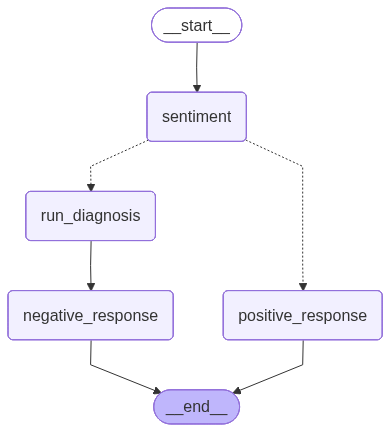

In [146]:
graph.add_edge(START,"sentiment")
graph.add_conditional_edges("sentiment",router)

graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow=graph.compile()
workflow

In [147]:
workflow.invoke({'review':'bad product'})

{'review': 'bad product',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Other',
  'tone': 'disappointed',
  'urgency': 'low'},
 'response': 'Hi there,\n\nI’m really sorry to hear that you’re feeling disappointed with your experience.\u202fI understand how frustrating that can be, and I’m here to help get things back on track.\n\n**Let’s work through this together**\n\n1. **Tell me a bit more** – Could you share the specific details of the issue you’re encountering? The more information you can provide (e.g., what you were trying to do, any error messages, the device or platform you’re using), the faster we can pinpoint a solution.\n\n2. **Check the basics** – While you’re gathering those details, you might want to try the following quick steps, which often resolve common hiccups:\n   * Refresh the page or restart the app.\n   * Clear your browser cache or reinstall the app.\n   * Ensure you’re using the latest version of the software.\n   * Verify that your internet connectio